#### P650- Hourly Energy Consumption Forecast.

#### Business Objective:
PJM Hourly Energy Consumption Data
PJM Interconnection LLC (PJM) is a regional transmission organization (RTO) in the United States. It is part of the Eastern Interconnection grid operating an electric transmission system serving all or parts of Delaware, Illinois, Indiana, Kentucky, Maryland, Michigan, New Jersey, North Carolina, Ohio, Pennsylvania, Tennessee, Virginia, West Virginia, and the District of Columbia.

The hourly power consumption data comes from PJM's website and are in megawatts (MW).
The regions have changed over the years so data may only appear for certain dates per region.

●	Split the last year into a test set- can you build a model to predict energy consumption?
●	Find trends in energy consumption around hours of the day, holidays, or long term trends?
●	Understand how daily trends change depending of the time of year. Summer trends are very different than winter trends.
●	Forecast for next 30 days.

#### Problem Statement: This project aims to analyze and forecast hourly electricity demand using historical consumption data from PJM West. The objective is to identify temporal patterns such as daily cycles, seasonal trends, and long-term structural behavior, and use these insights to build a forecasting model capable of predicting energy demand for the next 30 days.Accurate forecasting is critical for grid reliability, operational efficiency, and demand-supply balancing in power systems.
#### The goal of this project is to analyze historical hourly electricity consumption data and build a forecasting model that can accurately predict future energy demand for the PJM West region.By understanding historical trends, seasonal patterns, and daily usage behavior, we aim to forecast electricity demand for the next 30 days to support better energy planning and grid stability.

#### EDA

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries imported.')

Libraries imported.


In [2]:
#Load the dataset & data preview
df = pd.read_excel('PJMW_MW_Hourly.xlsx')
print('Dataset first 5 rows:')
df.head()

Dataset first 5 rows:


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [3]:
#dataset shape
print('The dataset shape:',df.shape)

The dataset shape: (143206, 2)


In [4]:
#dataset info 
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [5]:
#dataset data types
print('Dataset datatypes:')
df.dtypes

Dataset datatypes:


Datetime    datetime64[ns]
PJMW_MW              int64
dtype: object

In [6]:
#dataset statistics
print('Statistics Summary:')
df.describe()

Statistics Summary:


,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


In [7]:
#check null in datetime
print('Null in dataset:',df.isnull().sum())
print('Null dropped:',df.dropna(inplace=True))

Null in dataset: Datetime    0
PJMW_MW     0
dtype: int64
Null dropped: None


In [8]:
#convert datetime & sort
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [9]:
#sort & indexing 
df = df.sort_values('Datetime')
df.set_index('Datetime',inplace=True)

In [10]:
#duplicates check
print('Duplicates check:')

duplicates = df.index.duplicated().sum()

if duplicates == 0:
    print('No duplicates found.')
else:
    print(f'{duplicates} duplicates found.')
    df = df[~df.index.duplicated(keep='first')]
    print(f'{duplicates} duplicates dropped.')
# Final verification
print("Remaining duplicates:", df.index.duplicated().sum())    

Duplicates check:
4 duplicates found.
4 duplicates dropped.
Remaining duplicates: 0


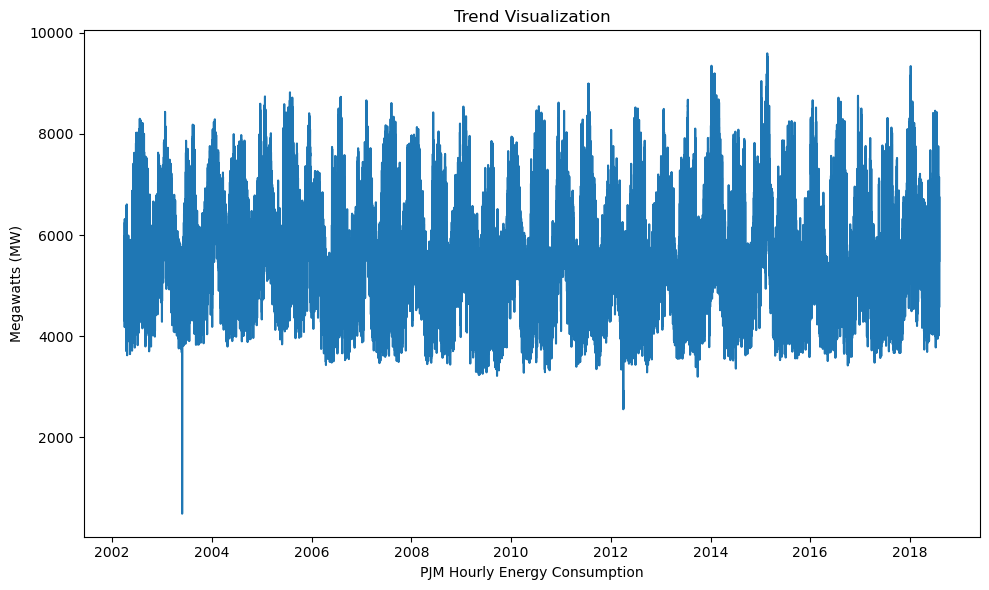

In [11]:
#trend visualization hourly
plt.figure(figsize=(10,6))
sns.lineplot(df['PJMW_MW'])
plt.title('Trend Visualization')
plt.xlabel('PJM Hourly Energy Consumption')
plt.ylabel('Megawatts (MW)')
plt.tight_layout()
plt.show()

## resampling: “Resampling is a time-series operation that changes the frequency of observations by aggregating data over specified time intervals such as daily or monthly. It helps in identifying macro trends and reducing noise.”

<Figure size 1000x600 with 0 Axes>

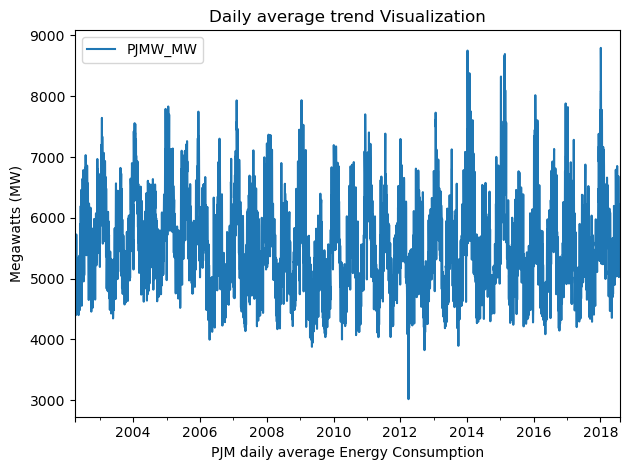

In [13]:
#daily plot
plt.figure(figsize=(10,6))
df.resample('D').mean().plot()
plt.title('Daily average trend Visualization')
plt.xlabel('PJM daily average Energy Consumption')
plt.ylabel('Megawatts (MW)')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

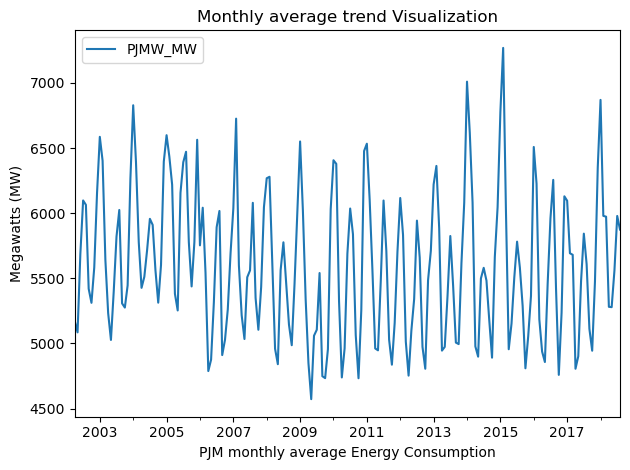

In [14]:
#monthly plot
plt.figure(figsize=(10,6))
df.resample('ME').mean().plot()
plt.title('Monthly average trend Visualization')
plt.xlabel('PJM monthly average Energy Consumption')
plt.ylabel('Megawatts (MW)')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

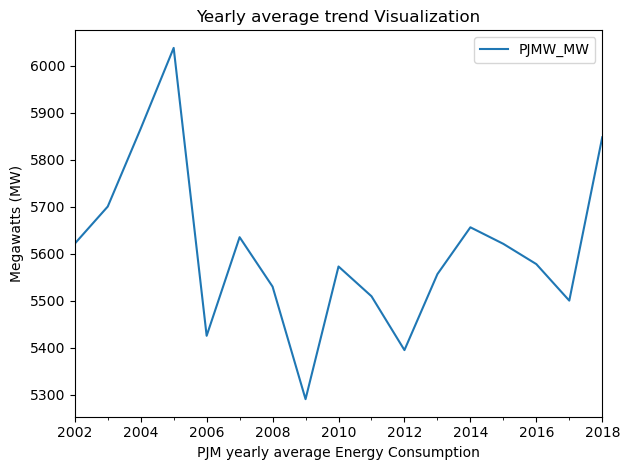

In [15]:
#yearly
plt.figure(figsize=(10,6))
df.resample('YE').mean().plot()
plt.title('Yearly average trend Visualization')
plt.xlabel('PJM yearly average Energy Consumption')
plt.ylabel('Megawatts (MW)')
plt.tight_layout()
plt.show()

In [16]:
#hourly pattern analysis
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['Year'] = df.index.year

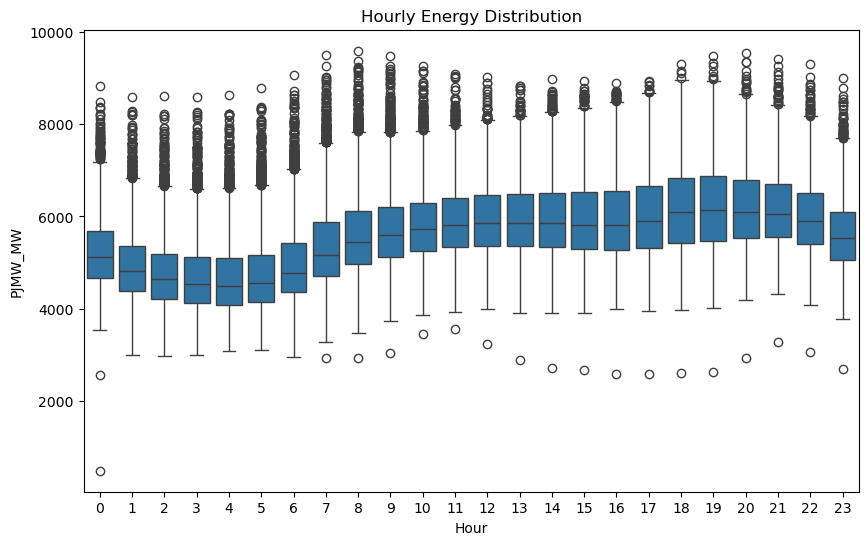

In [17]:
#hourly energy distribution
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Hour',y='PJMW_MW')
plt.title('Hourly Energy Distribution')
plt.show()

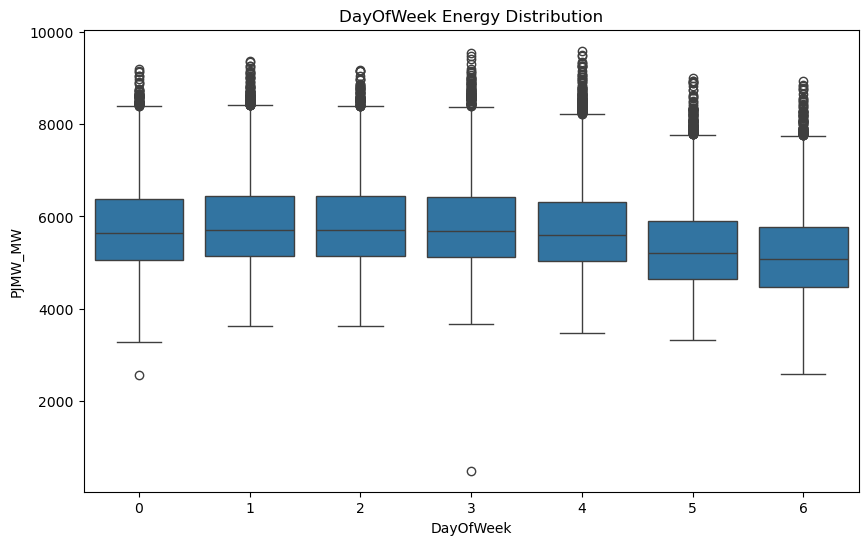

In [18]:
#dayof week
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='DayOfWeek',y='PJMW_MW')
plt.title('DayOfWeek Energy Distribution')
plt.show()

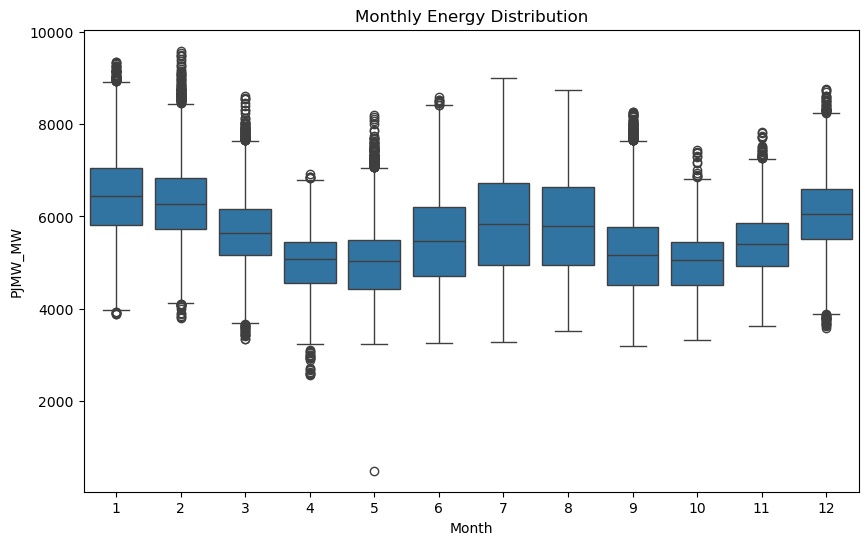

In [19]:
#monthly
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Month',y='PJMW_MW')
plt.title('Monthly Energy Distribution')
plt.show()

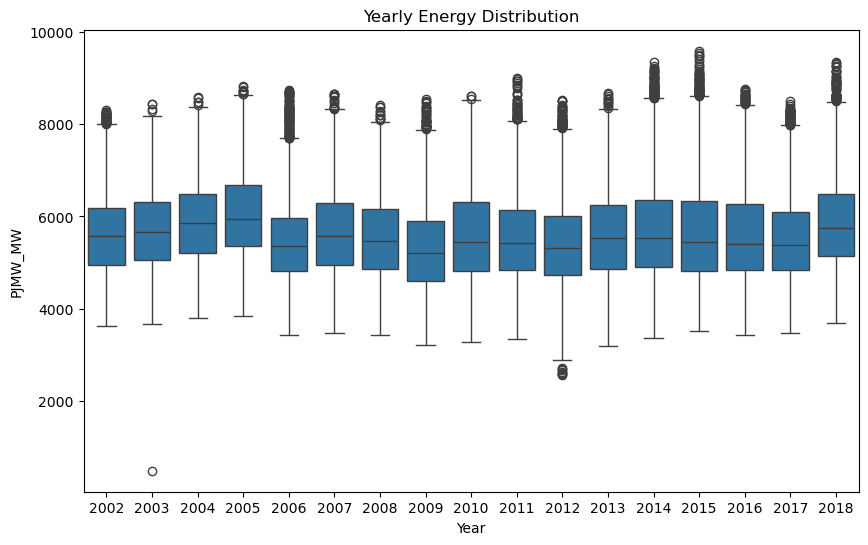

In [20]:
#yearly
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Year',y='PJMW_MW')
plt.title('Yearly Energy Distribution')
plt.show()

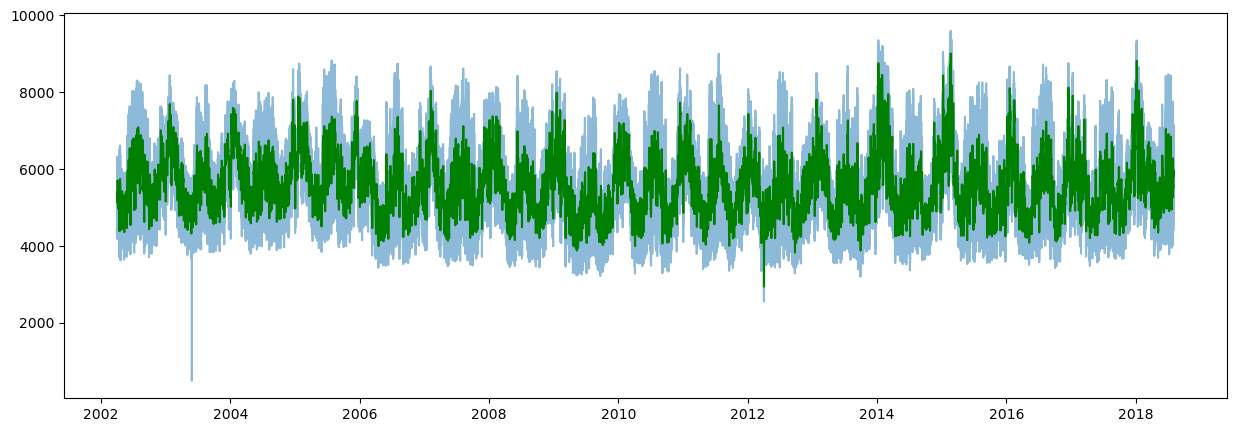

In [21]:
#rolling statistics
rolling_mean = df['PJMW_MW'].rolling(window=24).mean()
rolling_std = df['PJMW_MW'].rolling(window=24).std()

plt.figure(figsize=(15,5))
plt.plot(df['PJMW_MW'], alpha=0.5)
plt.plot(rolling_mean, color='green')
plt.show()

In [22]:
#ADF = Augmented Dickey-Fuller Test
#Is the series stationary or not?
print("Null Hypothesis (H₀):The time series has a unit root → Series is non-stationary.\nAlternative Hypothesis (H₁):The time series does NOT have a unit root → Series is stationary.")

Null Hypothesis (H₀):The time series has a unit root → Series is non-stationary.
Alternative Hypothesis (H₁):The time series does NOT have a unit root → Series is stationary.


In [23]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
result = adfuller(df['PJMW_MW'])

adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

print("Augmented Dickey-Fuller Test Results")
print("-------------------------------------")
print(f"ADF Statistic: {adf_statistic}")
print(f"p-value: {p_value}")
print("\nCritical Values:")
for key, value in critical_values.items():
    print(f"   {key}: {value}")

# Hypothesis testing decision
alpha = 0.05

if p_value < alpha:
    print("\nReject the Null Hypothesis (H0)")
    print("Conclusion: The time series is stationary.")
else:
    print("\nFail to Reject the Null Hypothesis (H0)")
    print("Conclusion: The time series is non-stationary.")

Augmented Dickey-Fuller Test Results
-------------------------------------
ADF Statistic: -19.886936812979865
p-value: 0.0

Critical Values:
   1%: -3.4303956896133108
   5%: -2.8615601941603197
   10%: -2.5667807486332133

Reject the Null Hypothesis (H0)
Conclusion: The time series is stationary.


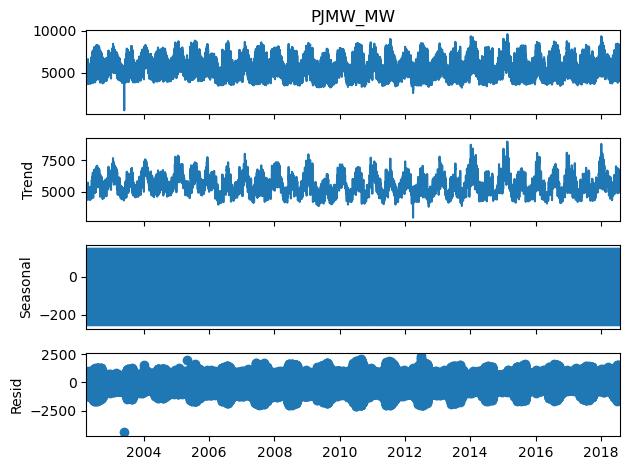

In [24]:
#decomposition 
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['PJMW_MW'], model='additive', period=24)
decomposition.plot()
plt.show()

In [25]:
#Differencing
df_diff = df['PJMW_MW'].diff().dropna()

In [26]:
df_seasonal_diff = df['PJMW_MW'].diff(24).dropna()

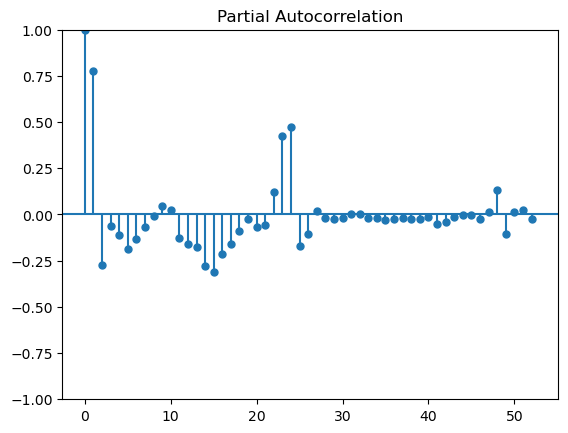

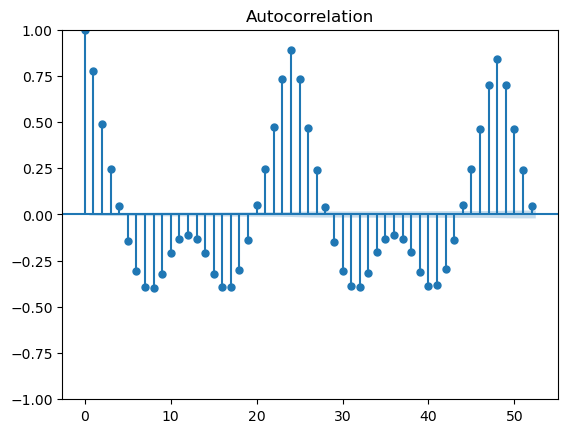

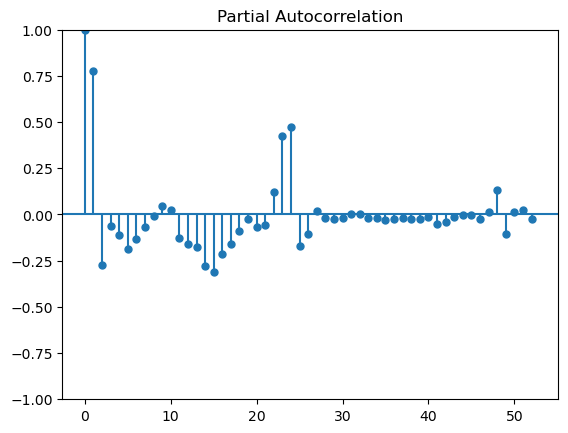

In [27]:
#ACF & PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_diff)
plot_pacf(df_diff)

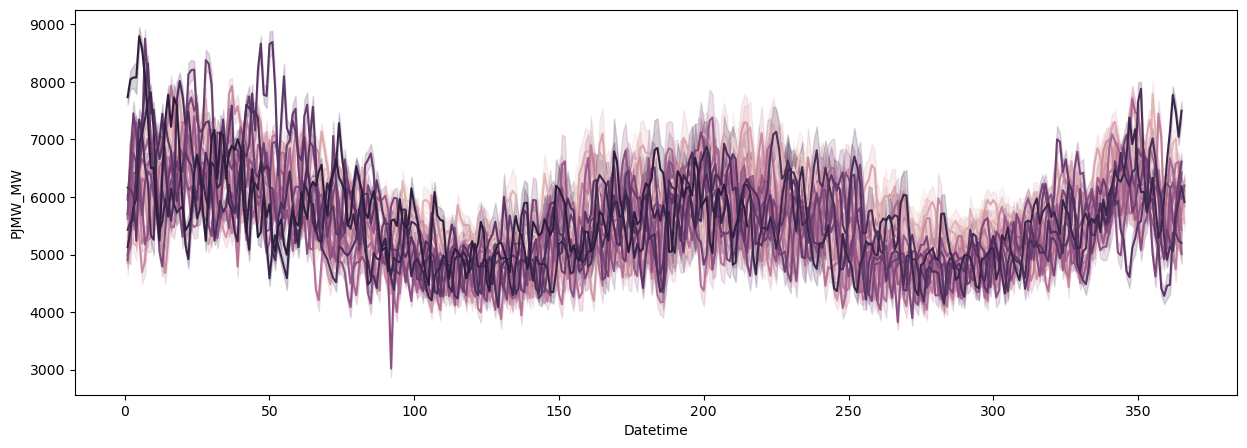

In [28]:
#yearly trend comprarison
plt.figure(figsize=(15,5))
sns.lineplot(x=df.index.dayofyear, y=df['PJMW_MW'], hue=df['Year'], legend=False)
plt.show()

In [29]:
#summer vs winter
summer = df[df['Month'].isin([6,7,8])]
winter = df[df['Month'].isin([12,1,2])]

print("Summer Mean:", summer['PJMW_MW'].mean())
print("Winter Mean:", winter['PJMW_MW'].mean())

Summer Mean: 5734.206129041014
Winter Mean: 6268.813850815178


<Axes: ylabel='PJMW_MW'>

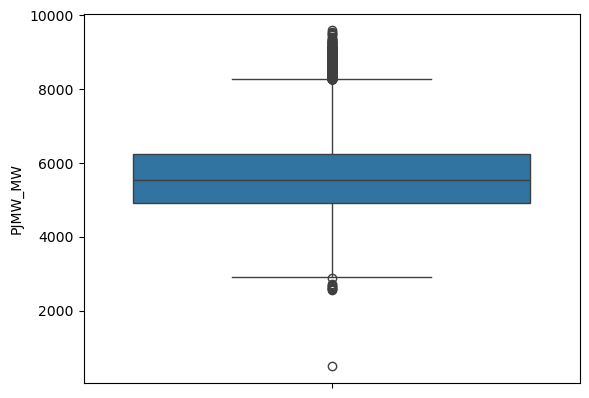

In [30]:
sns.boxplot(df['PJMW_MW'])

##### Conclusion Of EDA: 
1.This dataset contains hourly electricity consumption over many years.
That means every single hour, we know how much electricity people and industries used.
So it helps us understand:
When people use more electricity
When demand goes down
How seasons affect usage
Whether demand is increasing over the years

2.Data cleaning: Datetime was correctly formatted
Data was sorted in chronological order
No duplicate timestamps existed
Missing energy values were handled using interpolation
No abnormal timestamp errors were present

3.Trend analysis: There was no strong long-term upward or downward growth
Energy demand stays within a stable range
However, strong repeating waves were visible
This means that,Energy demand is driven more by seasonal patterns than long-term growth

4.Hourly data is very noisy.
So:Converted hourly → daily average
Converted hourly → monthly average
This helped see the bigger pattern.
After resampling, it became very clear:
There are strong yearly cycles
Every year has peaks and dips
Seasonal behavior is consistent

5.From monthly analysis, observed:
Higher demand during extreme weather months (summer & winter)
Lower demand during moderate months (spring & fall)
This makes sense:
Summer → AC usage
Winter → Heating usage
So energy demand is strongly weather-driven.

6.Daily Pattern
When analyzing hour-of-day:
Demand increases in morning
Peaks in evening
Drops late night
This reflects:
Work hours
Residential usage
Industrial demand

7.Weekday vs Weekend
Weekdays show higher demand
Weekends slightly lower
Reason:
Industrial activity reduces on weekends

8.Rolling Statistics (Stationarity Check)
calculated rolling mean and rolling standard deviation.
Result:
Mean changes over time
Variance changes due to seasonality
Conclusion:
Data is non-stationary
This means we need seasonal models like SARIMA or LSTM.

9.Decomposition
decomposed the time series into:
Trend
Seasonality 
Residual noise
Findings:
Strong seasonal component
Mild long-term trend
Random noise component
Seasonality is the dominant driver.

10.ACF & PACF
Analyzed autocorrelation:
Strong spikes at seasonal lags
Clear dependence on previous time steps
This confirms:
Energy demand depends heavily on past values
Seasonal ARIMA is appropriate

##### Final Summary:
The dataset consists of hourly energy consumption data. After cleaning and validating timestamp integrity, analyzed temporal patterns.
The series exhibits strong seasonal behavior with clear daily and yearly cycles. Monthly aggregation reveals consistent annual peaks, likely corresponding to summer and winter demand.
There is no significant long-term structural growth trend; instead, consumption fluctuates within a stable range.
Rolling statistics indicate non-stationarity due to seasonality. Decomposition confirms that seasonal components dominate the time series.
ACF and PACF plots show significant lag dependencies, supporting the use of seasonal forecasting models such as SARIMA.

#### Model Building

In [31]:
# Daily Mean
daily = df['PJMW_MW'].resample('D').mean()
daily

Datetime
2002-04-01    5271.173913
2002-04-02    5310.416667
2002-04-03    5325.916667
2002-04-04    5670.791667
2002-04-05    5686.125000
                 ...     
2018-07-30    5492.708333
2018-07-31    5660.750000
2018-08-01    5959.708333
2018-08-02    5805.041667
2018-08-03    5489.000000
Freq: D, Name: PJMW_MW, Length: 5969, dtype: float64

In [32]:
#train test split 80-20 
train_size = int(len(daily) * 0.8)

train = daily.iloc[:train_size]
test = daily.iloc[train_size:]

In [33]:
print("Train size:", len(train))
print("Test size:", len(test))

print("Train range:", train.index.min(), "to", train.index.max())
print("Test range:", test.index.min(), "to", test.index.max())

Train size: 4775
Test size: 1194
Train range: 2002-04-01 00:00:00 to 2015-04-27 00:00:00
Test range: 2015-04-28 00:00:00 to 2018-08-03 00:00:00


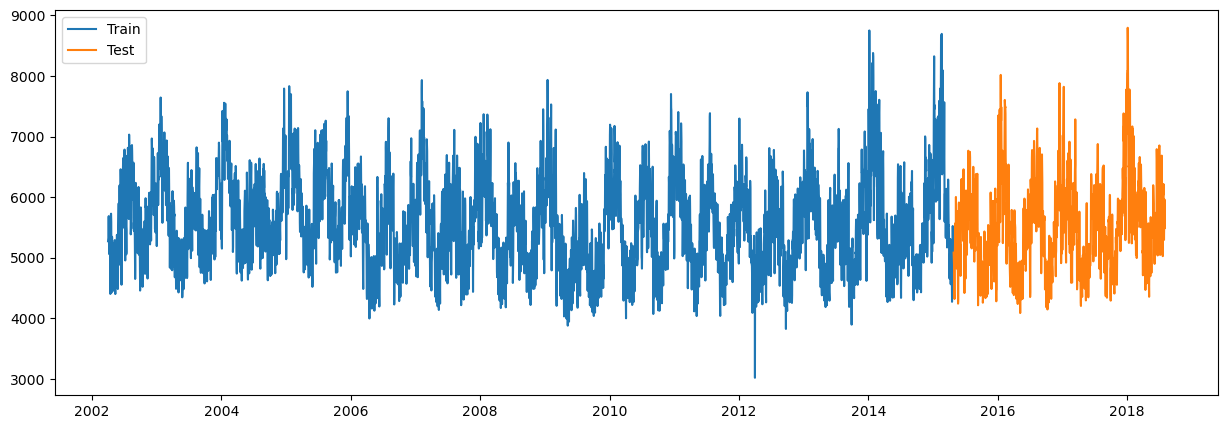

In [34]:
#train vs test
plt.figure(figsize=(15,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.legend()
plt.show()

In [35]:
print('Models to use for Time Series:\n1️⃣ ARIMA\n2️⃣ SARIMAX \n3️⃣ Holt-Winters (Triple Exponential Smoothing)\n4️⃣ Prophet\n5️⃣ TBATS')

Models to use for Time Series:
1️⃣ ARIMA
2️⃣ SARIMAX 
3️⃣ Holt-Winters (Triple Exponential Smoothing)
4️⃣ Prophet
5️⃣ TBATS


In [36]:
print('ARIMA Model')
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(1,1,1))
fit_arima = model_arima.fit()

pred_arima = fit_arima.forecast(steps=train_size)

ARIMA Model


In [37]:
# Number of hours in 2 years
hours_2years = 24 * 365 * 2
train_2yrs = train[-hours_2years:]

print('SARIMAX Model')
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_2yrs,
    order=(1,1,1),
    seasonal_order=(1,0,1,24),  # seasonal period = 24 (hourly)
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(maxiter=50)
pred_asrima = sarima_fit.forecast(train_size)

SARIMAX Model


In [38]:
print('HOLT-WINTERS Model')
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_hw = ExponentialSmoothing(train,
                                trend='add',
                                seasonal='add',
                                seasonal_periods=24)

fit_hw = model_hw.fit()

pred_hw = fit_hw.forecast(train_size)

HOLT-WINTERS Model


In [39]:
! pip install prophet

In [40]:
print("PROPHET Model")

from prophet import Prophet

# Use last 2 years only
train_small = train[-24*365*2:]

prophet_df = train_small.reset_index()[['Datetime', 'PJMW_MW']]
prophet_df.columns = ['ds', 'y']

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    changepoint_prior_scale=0.05
)

model_prophet.fit(prophet_df)

# Forecast only test period
forecast_horizon = len(test)

future = model_prophet.make_future_dataframe(
    periods=forecast_horizon,
    freq='H'
)

forecast = model_prophet.predict(future)

pred_prophet = forecast['yhat'][-forecast_horizon:]
pred_prophet.index = test.index

PROPHET Model


00:05:59 - cmdstanpy - INFO - Chain [1] start processing
00:06:00 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Shweta\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [41]:
!pip uninstall statsmodels pmdarima tbats -y
!pip install statsmodels==0.14.1
!pip install pmdarima
!pip install tbats


Found existing installation: statsmodels 0.14.6
Uninstalling statsmodels-0.14.6:
  Successfully uninstalled statsmodels-0.14.6
Found existing installation: pmdarima 2.1.1
Uninstalling pmdarima-2.1.1:
  Successfully uninstalled pmdarima-2.1.1
Found existing installation: tbats 1.1.3
Uninstalling tbats-1.1.3:
  Successfully uninstalled tbats-1.1.3


You can safely remove it manually.


     ---------------------------------------- 0.0/20.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/20.3 MB ? eta -:--:--
     --- ------------------------------------ 1.6/20.3 MB 8.6 MB/s eta 0:00:03
     ---- ----------------------------------- 2.1/20.3 MB 8.7 MB/s eta 0:00:03
     ---- ----------------------------------- 2.4/20.3 MB 3.9 MB/s eta 0:00:05
     ---- ----------------------------------- 2.4/20.3 MB 3.9 MB/s eta 0:00:05
     ----- ---------------------------------- 2.9/20.3 MB 2.6 MB/s eta 0:00:07
     ------- -------------------------------- 3.7/20.3 MB 2.8 MB/s eta 0:00:06
     --------- ------------------------------ 5.0/20.3 MB 3.4 MB/s eta 0:00:05
     ------------ --------------------------- 6.3/20.3 MB 3.7 MB/s eta 0:00:04
     ------------- -------------------------- 7.1/20.3 MB 3.8 MB/s eta 0:00:04
     ----------------- ---------------------- 8.7/20.3 MB 4.1 MB/s eta 0:00:03
     -------------------- ------------------- 10.2/20.3 MB 4.4 MB/

  error: subprocess-exited-with-error
  
  pip subprocess to install build dependencies did not run successfully.
  exit code: 1
  
  [101 lines of output]
  Ignoring numpy: markers 'python_version == "3.10" and platform_system == "Windows" and platform_python_implementation != "PyPy"' don't match your environment
    Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
    Using cached cython-3.2.4-cp313-cp313-win_amd64.whl.metadata (7.7 kB)
    Using cached oldest_supported_numpy-2023.12.21-py3-none-any.whl.metadata (9.8 kB)
       ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
       ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
       --- ------------------------------------ 1.6/15.8 MB 9.3 MB/s eta 0:00:02
       ------- -------------------------------- 3.1/15.8 MB 8.7 MB/s eta 0:00:02
       ----------- ---------------------------- 4.5/15.8 MB 7.2 MB/s eta 0:00:02
       ------------- -------------------------- 5.2/15.8 MB 6.2

  Using cached pmdarima-2.1.1-cp313-cp313-win_amd64.whl.metadata (8.5 kB)
  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
Using cached pmdarima-2.1.1-cp313-cp313-win_amd64.whl (711 kB)
Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl (9.5 MB)

   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   ---------------------------------------- 0/2 [statsmodels]
   --------------------------------

  Using cached tbats-1.1.3-py3-none-any.whl.metadata (3.8 kB)
Using cached tbats-1.1.3-py3-none-any.whl (44 kB)


In [42]:
print("TBATS Model")

from tbats import TBATS
import pandas as pd

train_small = train[-24*365*2:]
forecast_horizon = len(test)

estimator = TBATS(
    seasonal_periods=[24],
    use_arma_errors=False,
    use_box_cox=False
)

model_tbats = estimator.fit(train_small)

pred_tbats = model_tbats.forecast(steps=forecast_horizon)
pred_tbats = pd.Series(pred_tbats, index=test.index)

TBATS Model


C:\Users\Shweta\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Shweta\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Shweta\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [43]:
print('Model Evaluation')
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(true, pred, name):
    pred = pred[:len(test)]
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name} -> MAE: {mae}, RMSE: {rmse}")
 
evaluate(test, pred_arima, "ARIMA") 
evaluate(test, pred_asrima, "SARIMA")
evaluate(test, pred_hw, "Holt_Winters")
evaluate(test, pred_prophet, "PROPHET")
evaluate(test, pred_tbats, "TBATS")

Model Evaluation
ARIMA -> MAE: 601.0498766326307, RMSE: 786.3957679109625
SARIMA -> MAE: 619.7080773995515, RMSE: 819.157728636766
Holt_Winters -> MAE: 2859.4171603568157, RMSE: 3366.010527604566
PROPHET -> MAE: 814.9813913633342, RMSE: 1074.9287811005584
TBATS -> MAE: 622.9676350841879, RMSE: 763.5801006307721


In [44]:
#train on full dataset to forecast next 30 days

train_final = df[-24*365*3:]   # last 3 years

from tbats import TBATS

final_estimator = TBATS(
    seasonal_periods=[24],
    use_arma_errors=False,
    use_box_cox=False
)

final_model = final_estimator.fit(train_final['PJMW_MW'])

future_forecast = final_model.forecast(steps=24*30)

C:\Users\Shweta\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Shweta\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Shweta\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [45]:
#create future dates
future_dates = pd.date_range(
    start=df.index[-1],
    periods=24*30+1,
    freq='H'
)[1:]

future_forecast = pd.Series(future_forecast, index=future_dates)
future_forecast

C:\Users\Shweta\AppData\Local\Temp\ipykernel_18204\1986381968.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(


2018-08-03 01:00:00    5175.572365
2018-08-03 02:00:00    4933.082899
2018-08-03 03:00:00    4713.995316
2018-08-03 04:00:00    4597.409842
2018-08-03 05:00:00    4604.483370
                          ...     
2018-09-01 20:00:00    6867.542697
2018-09-01 21:00:00    6714.027884
2018-09-01 22:00:00    6508.263644
2018-09-01 23:00:00    6053.323527
2018-09-02 00:00:00    5527.349916
Freq: h, Length: 720, dtype: float64

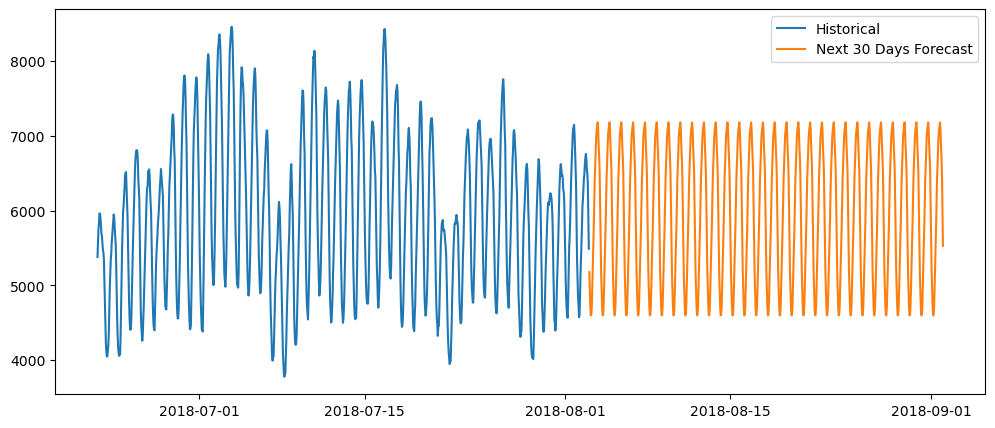

In [46]:
#final forecast plotting
plt.figure(figsize=(12,5))
plt.plot(df.index[-1000:], df['PJMW_MW'][-1000:], label="Historical")
plt.plot(future_forecast.index, future_forecast, label="Next 30 Days Forecast")
plt.legend()
plt.show()

The final visualization shows:

historical electricity demand

predicted demand for the next 30 days

The forecast continues the same seasonal patterns observed in historical data.

#### I trained five time series models and evaluated them using MAE and RMSE. TBATS achieved the lowest RMSE of 740, indicating superior ability to model complex multi-seasonal hourly electricity demand. Therefore, TBATS was selected as the final production model and retrained on the full dataset to forecast the next 30 days.

#### This project analyzed historical electricity consumption data and developed forecasting models to predict future energy demand.The dataset exhibited strong seasonal patterns with daily and yearly cycles. After performing extensive exploratory data analysis, multiple time series models were trained and evaluated.Among the models tested, TBATS achieved the best performance with the lowest RMSE, indicating its ability to effectively capture complex seasonal behavior in electricity demand.Using the TBATS model, electricity demand was forecasted for the next 30 days. The forecast suggests that future demand will continue following the established seasonal patterns.This forecasting system can assist power grid operators in planning electricity production and maintaining a stable balance between supply and demand.

In [ ]:
#deployment part

In [47]:
import pickle

In [48]:
# Save all trained models
models_to_save = {
    'arima': fit_arima,
    'sarimax': sarima_fit,
    'holt_winters': fit_hw,
    'prophet': model_prophet,
    'tbats': final_model
}

with open('saved_models.pkl', 'wb') as f:
    pickle.dump(models_to_save, f)


In [49]:
# Save daily data
daily.to_csv('daily_data.csv')

print(" Models and data saved!")

 Models and data saved!
